# NLP Challenge: Fake News Detection

### Overview
Build a machine learning classifier to distinguish between **Real (1)** and **Fake (0)** news headlines.

### Data
* **Training:** `training_data_lowercase.csv` (labeled).
* **Validation:** `testing_data_lowercase_nolabels.csv` (label `2` to be predicted).

### Objectives
* Preprocess text (clean noise, remove stopwords).
* Convert text to numerical vectors.
* Train and evaluate a classifier.
* Generate final predictions for the validation set.

## 1. Importing Libraries and Loading Data

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Visuals & Metrics
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Vectorization & Models
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


# Setup NLTK
nltk.download('stopwords')
nltk.download('wordnet')

print("Environment Ready.")

Environment Ready.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
# Load Training Data
train_df = pd.read_csv('/content/training_data_lowercase.csv', sep='\t', header=None, names=['label', 'text'])

# Load Validation Data (The one to predict)
val_df = pd.read_csv('/content/testing_data_lowercase_nolabels.csv', sep='\t', header=None, names=['label', 'text'])

print(f"Training shapes: {train_df.shape}")
print(train_df.head())

Training shapes: (34152, 2)
   label                                               text
0      0  donald trump sends out embarrassing new year‚s...
1      0  drunk bragging trump staffer started russian c...
2      0  sheriff david clarke becomes an internet joke ...
3      0  trump is so obsessed he even has obama‚s name ...
4      0  pope francis just called out donald trump duri...


## 2. Data Preprocessing


In [5]:
stop_words = set(stopwords.words('english'))

def final_clean_no_dates(text):
    # 1. Convert to lowercase
    text = str(text).lower()

    # 2. Strict Regex: Remove everything except letters (a-z) and spaces
    # This specifically deletes numbers (0-9) and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize and remove stopwords
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]

    return " ".join(cleaned_words)

# Apply cleaning to both datasets
train_df['preprocessed_text'] = train_df['text'].apply(final_clean_no_dates)
val_df['preprocessed_text'] = val_df['text'].apply(final_clean_no_dates)

# Verification: Print 10 samples of each category

# Select indices for 10 Fake (0) and 10 Real (1) articles
fake_indices = train_df[train_df['label'] == 0].head(5).index.tolist()
real_indices = train_df[train_df['label'] == 1].head(5).index.tolist()
all_indices = fake_indices + real_indices

print(f"{'LBL':<4} | {'TYPE':<6} | {'ORIGINAL TEXT':<50} | {'CLEANED (NO DATES)'}")
print("-" * 145)

for i in all_indices:
    label = train_df['label'].iloc[i]
    original = train_df['text'].iloc[i]
    cleaned = train_df['preprocessed_text'].iloc[i]

    label_text = "FAKE" if label == 0 else "REAL"
    # Truncate original text for better display
    orig_short = (original[:47] + '..') if len(original) > 47 else original

    print(f"{label:<4} | {label_text:<6} | {orig_short:<50} | {cleaned}")
    #print(f"{label:<4} | {label_text:<6} | {cleaned}")

LBL  | TYPE   | ORIGINAL TEXT                                      | CLEANED (NO DATES)
-------------------------------------------------------------------------------------------------------------------------------------------------
0    | FAKE   | donald trump sends out embarrassing new year‚s ..  | donald trump sends embarrassing new years eve message disturbing
0    | FAKE   | drunk bragging trump staffer started russian co..  | drunk bragging trump staffer started russian collusion investigation
0    | FAKE   | sheriff david clarke becomes an internet joke f..  | sheriff david clarke becomes internet joke threatening poke people eye
0    | FAKE   | trump is so obsessed he even has obama‚s name c..  | trump obsessed even obamas name coded website images
0    | FAKE   | pope francis just called out donald trump durin..  | pope francis called donald trump christmas speech
1    | REAL   | as u.s. budget fight looms	republicans flip the..  | us budget fight looms republicans flip fisca

## 3. Stemming


In [6]:
## 3. Stemming Implementation
from nltk.stem import SnowballStemmer

# Initialize the Snowball Stemmer for the English language
stemmer = SnowballStemmer("english")

def apply_snowball_stemming(text):
    # Words are split, stemmed individually, and reconstructed into a string
    words = text.split()
    stemmed_words = [stemmer.stem(w) for w in words]
    return " ".join(stemmed_words)

# Stemming is applied to the preprocessed (cleaned) text
train_df['stemmed_text'] = train_df['preprocessed_text'].apply(apply_snowball_stemming)
val_df['stemmed_text'] = val_df['preprocessed_text'].apply(apply_snowball_stemming)

# Verification of the transformation
fake_indices = train_df[train_df['label'] == 0].head(10).index.tolist()
real_indices = train_df[train_df['label'] == 1].head(10).index.tolist()
selected_indices = fake_indices + real_indices

print(f"{'LBL':<4} | {'TYPE':<6} | {'SNOWBALL STEMMED TEXT'}")
print("-" * 120)

for i in selected_indices:
    label = train_df['label'].iloc[i]
    label_text = "FAKE" if label == 0 else "REAL"
    stemmed = train_df['stemmed_text'].iloc[i]

    # We print the full stemmed text to see the algorithm's effect
    print(f"{label:<4} | {label_text:<6} | {stemmed}")

LBL  | TYPE   | SNOWBALL STEMMED TEXT
------------------------------------------------------------------------------------------------------------------------
0    | FAKE   | donald trump send embarrass new year eve messag disturb
0    | FAKE   | drunk brag trump staffer start russian collus investig
0    | FAKE   | sheriff david clark becom internet joke threaten poke peopl eye
0    | FAKE   | trump obsess even obama name code websit imag
0    | FAKE   | pope franci call donald trump christma speech
0    | FAKE   | racist alabama cop brutal black boy handcuff graphic imag
0    | FAKE   | fresh golf cours
0    | FAKE   | trump said insan racist stuff insid oval offic
0    | FAKE   | former cia director slam trump un bulli
0    | FAKE   | brandnew protrump ad featur much kiss make sick
1    | REAL   | us budget fight loom republican flip fiscal script
1    | REAL   | us militari accept transgend recruit monday pentagon
1    | REAL   | senior us republican senat let mr mueller job
1    |

## 3.2. Visualizing Word Frequencies (Fake vs Real)


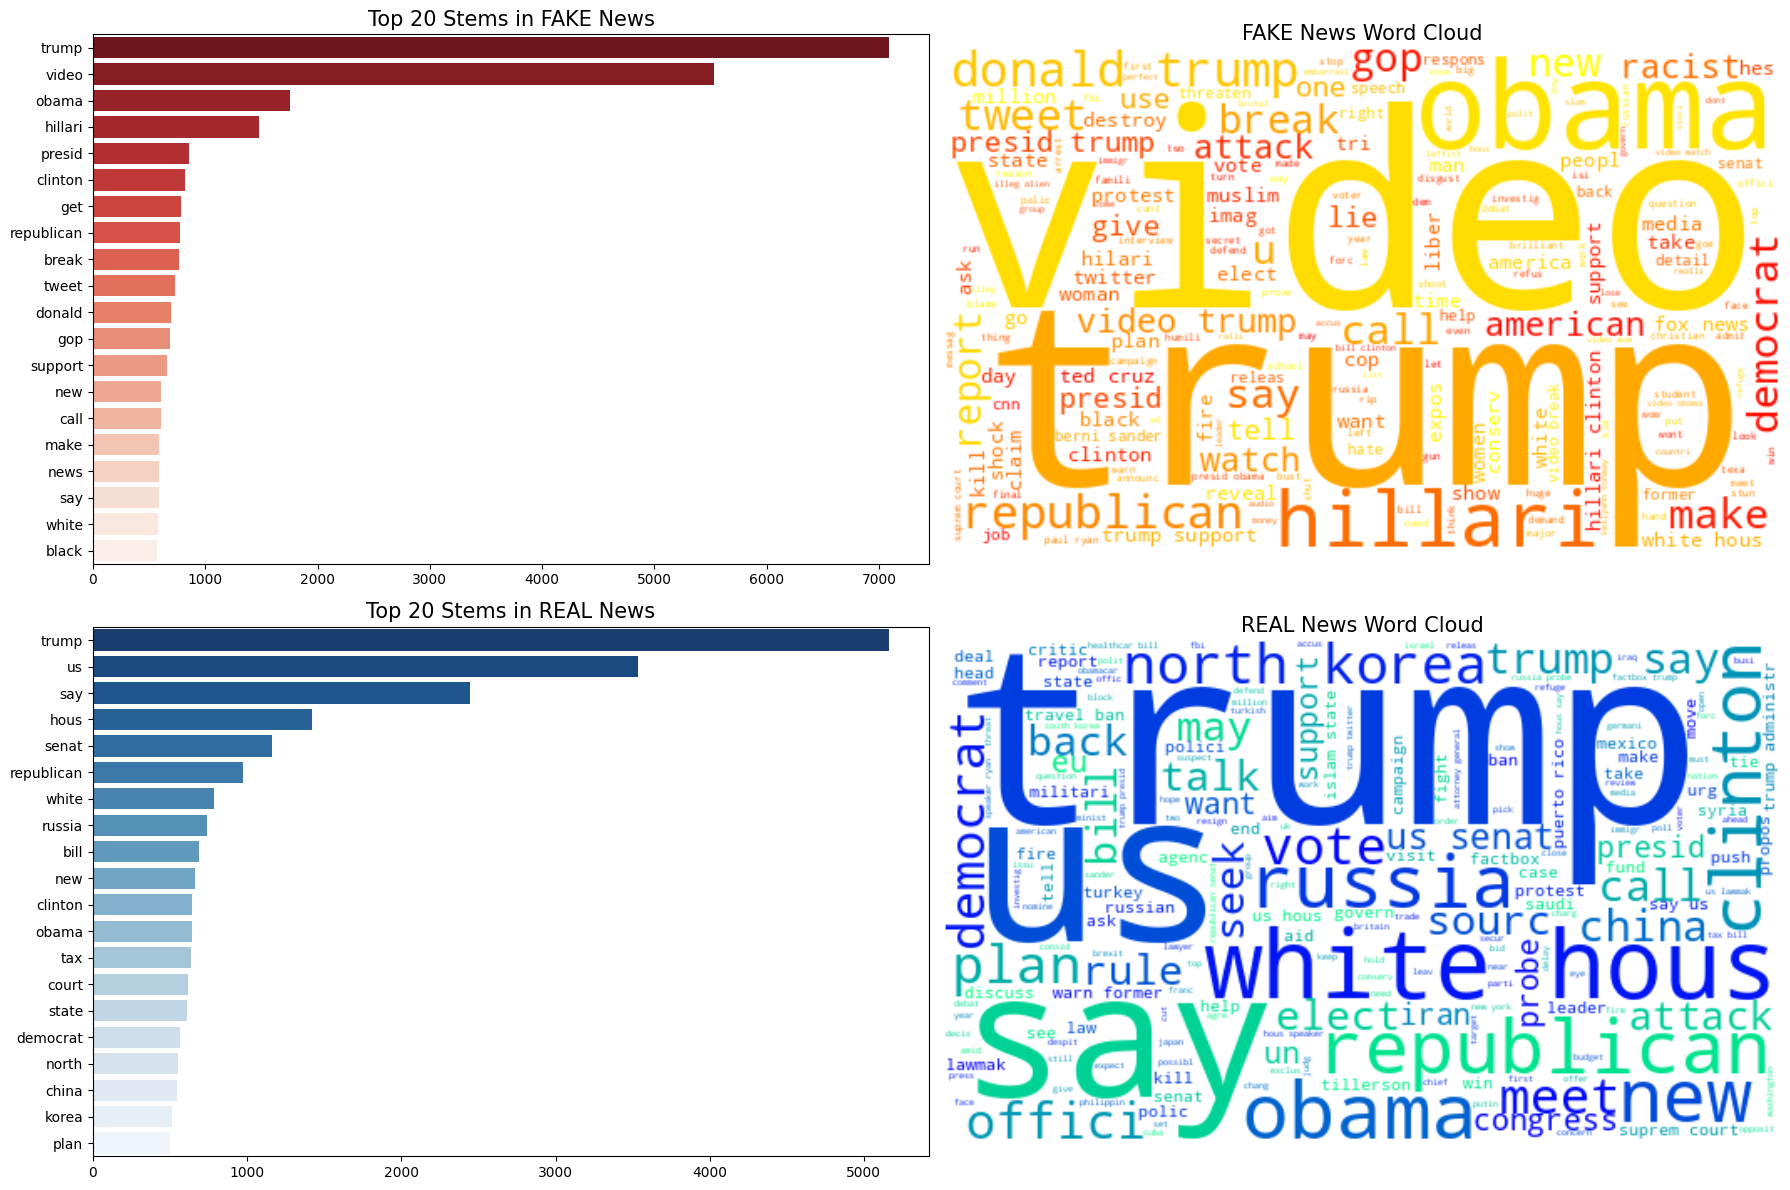

In [7]:
!pip install wordcloud
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# 1. Function to get top N words
def get_top_words(df, label, n=20):
    text = " ".join(df[df['label'] == label]['stemmed_text']).split()
    return Counter(text).most_common(n)

# 2. Setup the visualization area
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- FAKE NEWS VISUALS ---
fake_top_20 = get_top_words(train_df, 0)
words_f, counts_f = zip(*fake_top_20)
sns.barplot(x=list(counts_f), y=list(words_f), hue=list(words_f), ax=axes[0, 0], palette='Reds_r', legend=False)
axes[0, 0].set_title('Top 20 Stems in FAKE News', fontsize=15)

fake_text = " ".join(train_df[train_df['label'] == 0]['stemmed_text'])
wc_fake = WordCloud(width=500, height=300, background_color='white', colormap='autumn').generate(fake_text)
axes[0, 1].imshow(wc_fake, interpolation='bilinear')
axes[0, 1].set_title('FAKE News Word Cloud', fontsize=15)
axes[0, 1].axis('off')

# --- REAL NEWS VISUALS ---
real_top_20 = get_top_words(train_df, 1)
words_r, counts_r = zip(*real_top_20)
sns.barplot(x=list(counts_r), y=list(words_r), hue=list(words_f), ax=axes[1, 0], palette='Blues_r', legend=False)
axes[1, 0].set_title('Top 20 Stems in REAL News', fontsize=15)

real_text = " ".join(train_df[train_df['label'] == 1]['stemmed_text'])
wc_real = WordCloud(width=500, height=300, background_color='white', colormap='winter').generate(real_text)
axes[1, 1].imshow(wc_real, interpolation='bilinear')
axes[1, 1].set_title('REAL News Word Cloud', fontsize=15)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 4. Feature Engineering & Vectorization

In [8]:
## 4. Enhanced Vectorization (Feature Engineering)
from sklearn.feature_extraction.text import TfidfVectorizer

# We add:
# - ngram_range=(1, 2): captures both single words and two-word pairs
# - min_df=5: ignores words that appear in fewer than 5 articles (removes noise)
# - max_df=0.8: ignores words that appear in more than 80% of articles
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

# Fit and transform
X_train = tfidf.fit_transform(train_df['stemmed_text'])
X_val = tfidf.transform(val_df['stemmed_text'])
y_train = train_df['label']
y_val = val_df['label']

print(f"Features: {X_train.shape[1]} | Train: {X_train.shape[0]} | Val: {X_val.shape[0]}")

Features: 5000 | Train: 34152 | Val: 9984


### 4.1. Feature Importance Analysis


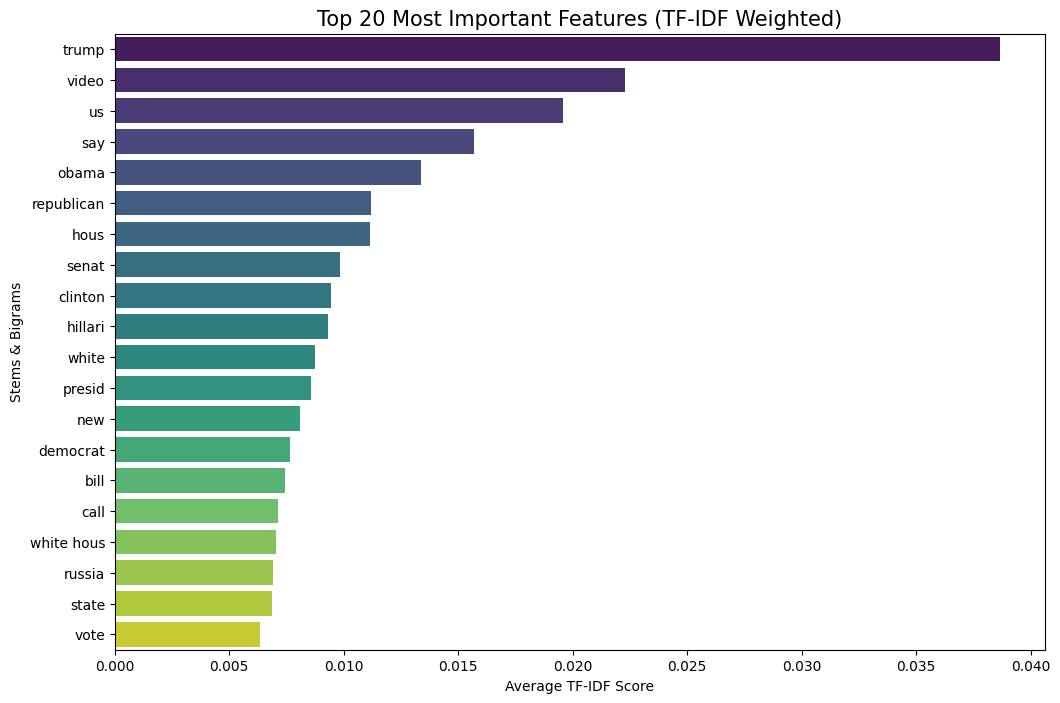

In [9]:
## 4.1. Visualizing TF-IDF Features
import pandas as pd
import numpy as np

# Get feature names (words/bigrams)
feature_names = tfidf.get_feature_names_out()

# Calculate mean TF-IDF scores across all documents
# This helps see which features are generally the most "important"
tfidf_scores = np.asarray(X_train.mean(axis=0)).ravel()
feature_importance = pd.DataFrame({'word': feature_names, 'tfidf_score': tfidf_scores})
feature_importance = feature_importance.sort_values(by='tfidf_score', ascending=False).head(20)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='tfidf_score', y='word', hue='word', data=feature_importance, palette='viridis', legend=False)
plt.title('Top 20 Most Important Features (TF-IDF Weighted)', fontsize=15)
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Stems & Bigrams')
plt.show()

## 5. Global Data Preparation


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Final split for all models (80% train, 20% validation)
train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

# 2. Global Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.8)

# Fit ONLY on train, transform both
X_train = tfidf.fit_transform(train_split['stemmed_text'])
X_val = tfidf.transform(val_split['stemmed_text'])

# Target variables
y_train = train_split['label'].astype(int)
y_val = val_split['label'].astype(int)

print(f"Data is ready for modeling!")
print(f"Training shape: {X_train.shape} | Validation shape: {X_val.shape}")

Data is ready for modeling!
Training shape: (27321, 5000) | Validation shape: (6831, 5000)


### 5.1. Logistic Regression


--- Logistic Regression Results ---
Train Accuracy: 0.9507
Val Accuracy: 0.9371
Train F1: 0.9494
Val F1: 0.9354

Detailed Classification Report (Validation Set):
              precision    recall  f1-score   support

    Fake (0)       0.94      0.94      0.94      3515
    Real (1)       0.93      0.94      0.94      3316

    accuracy                           0.94      6831
   macro avg       0.94      0.94      0.94      6831
weighted avg       0.94      0.94      0.94      6831



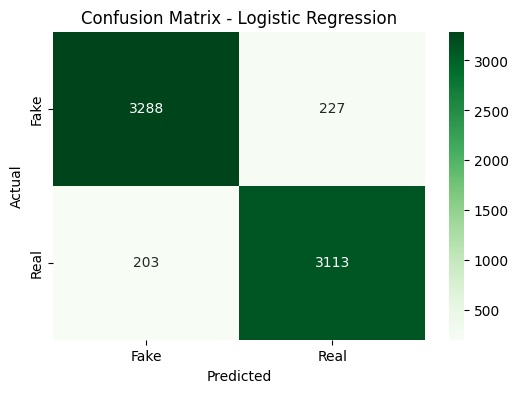

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Initialize and Train
lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_train, y_train)

# 2. Predictions
train_preds = lr_model.predict(X_train)
val_preds = lr_model.predict(X_val)

# 3. Calculate Metrics
metrics = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Val Accuracy": accuracy_score(y_val, val_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Val F1": f1_score(y_val, val_preds)
}

# 4. Display Results
print("--- Logistic Regression Results ---")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nDetailed Classification Report (Validation Set):")
print(classification_report(y_val, val_preds, target_names=['Fake (0)', 'Real (1)']))

# 5. Visualizing Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, val_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 6. Bag of Words with Multinomial Naive Bayes

--- Multinomial Naive Bayes Results ---
Train Accuracy: 0.9381
Val Accuracy: 0.9281
Train F1: 0.9358
Val F1: 0.9250

Detailed Classification Report (Validation Set):
              precision    recall  f1-score   support

    Fake (0)       0.92      0.94      0.93      3515
    Real (1)       0.94      0.91      0.93      3316

    accuracy                           0.93      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.93      0.93      0.93      6831



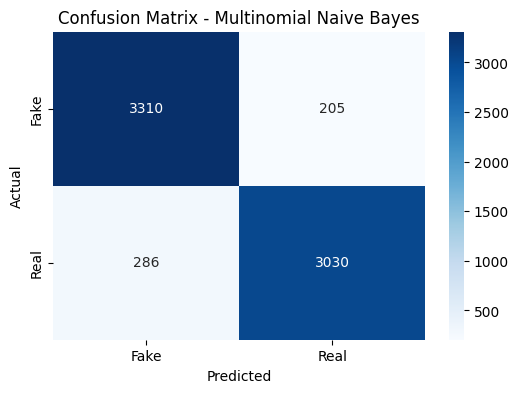

In [12]:
#Create bow Vectorizer
stemmed_bow = CountVectorizer(
    max_features = 5000,
    ngram_range = (1, 2),
    min_df = 5,
    max_df = 0.8
)
#Fit on training text and transform it into a numeric matrix
X_train_bow = stemmed_bow.fit_transform(train_split["stemmed_text"])

# Transform validation text using the same learned vocabulary
X_val_bow = stemmed_bow.transform(val_split["stemmed_text"])

#Extract Labels
y_train = train_split["label"].astype(int)
y_val = val_split["label"].astype(int)

#Initialize and train the model
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_bow, y_train)

#Predictions
train_preds = nb_model.predict(X_train_bow)
val_preds = nb_model.predict(X_val_bow)

#Calculate metrics
metrics = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Val Accuracy": accuracy_score(y_val, val_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Val F1": f1_score(y_val, val_preds)
}

#Display Results
print("--- Multinomial Naive Bayes Results ---")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nDetailed Classification Report (Validation Set):")
print(classification_report(y_val, val_preds, target_names=['Fake (0)', 'Real (1)']))

#Visualizing Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_val, val_preds),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# 7. Bag of Words with XGBoost

--- XGBoost Results ---
Train Accuracy: 0.9381
Val Accuracy: 0.8548
Train F1: 0.9358
Val F1: 0.8626

Detailed Classification Report (Validation Set):
              precision    recall  f1-score   support

    Fake (0)       0.93      0.77      0.85      3515
    Real (1)       0.80      0.94      0.86      3316

    accuracy                           0.85      6831
   macro avg       0.86      0.86      0.85      6831
weighted avg       0.87      0.85      0.85      6831



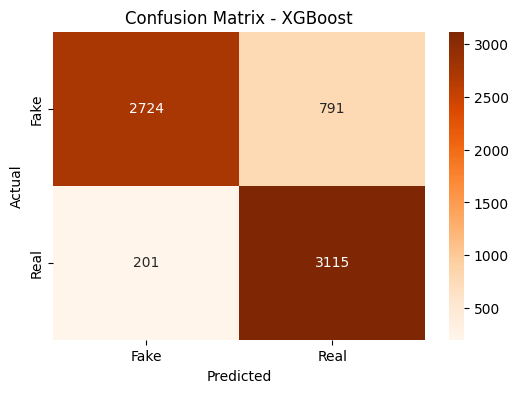

In [13]:
#Import
from xgboost import XGBClassifier

#Initialize and Train
xgb_model = XGBClassifier(
    n_estimators=100,        # Number of boosting trees
    max_depth=6,             # Maximum depth of each tree
    learning_rate=0.1,       # Step size for learning
    subsample=0.8,           # Use 80% of training samples per tree
    colsample_bytree=0.8,    # Use 80% of features per tree
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_bow, y_train)

#Predictions
train_pred = xgb_model.predict(X_train_bow)
val_preds = xgb_model.predict(X_val_bow)

#Calculate Metrics
metrics = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Val Accuracy": accuracy_score(y_val, val_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Val F1": f1_score(y_val, val_preds)
}

# 4. Display Results
print("--- XGBoost Results ---")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nDetailed Classification Report (Validation Set):")
print(classification_report(y_val, val_preds, target_names=['Fake (0)', 'Real (1)']))


# 5. Visualizing Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_val, val_preds),
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# 8. Bag of Words with RandomForest

---






--- Random Forest Results ---
Train Accuracy: 1.0000
Val Accuracy: 0.9198
Train F1: 1.0000
Val F1: 0.9165

Detailed Classification Report (Validation Set):
              precision    recall  f1-score   support

    Fake (0)       0.91      0.93      0.92      3515
    Real (1)       0.93      0.91      0.92      3316

    accuracy                           0.92      6831
   macro avg       0.92      0.92      0.92      6831
weighted avg       0.92      0.92      0.92      6831



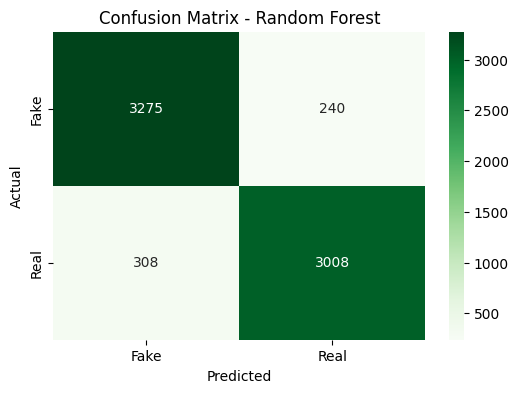

In [14]:
#Import
from sklearn.ensemble import RandomForestClassifier
#Initialize and train
rf_model = RandomForestClassifier(
    n_estimators=200,      # Number of trees
    max_depth=None,        # Trees grow fully unless stopped
    min_samples_split=2,   # Minimum samples to split a node
    min_samples_leaf=1,    # Minimum samples in leaf node
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

rf_model.fit(X_train_bow, y_train)

#Predictions
train_preds = rf_model.predict(X_train_bow)
val_preds = rf_model.predict(X_val_bow)


#Calculate Metrics
metrics = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Val Accuracy": accuracy_score(y_val, val_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Val F1": f1_score(y_val, val_preds)
}


#Display Results
print("--- Random Forest Results ---")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nDetailed Classification Report (Validation Set):")
print(classification_report(y_val, val_preds, target_names=['Fake (0)', 'Real (1)']))


#Visualizing Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_val, val_preds),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 9. Bag of Words with Linear SVC

--- LinearSVC Results ---
Train Accuracy: 0.9803
Val Accuracy: 0.9340
Train F1: 0.9798
Val F1: 0.9323

Detailed Classification Report (Validation Set):
              precision    recall  f1-score   support

    Fake (0)       0.94      0.93      0.94      3515
    Real (1)       0.93      0.94      0.93      3316

    accuracy                           0.93      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.93      0.93      0.93      6831



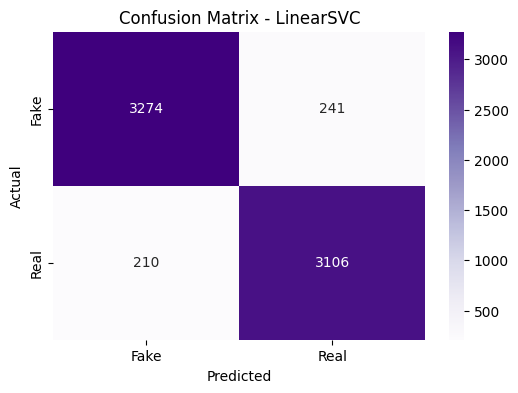

In [15]:
#Import
from sklearn.svm import LinearSVC

#Initialize and train
svm_model = LinearSVC(
    C=0.5,
    random_state=42,
    max_iter= 5000
)

svm_model.fit(X_train_bow, y_train)

#Predictions
train_preds = svm_model.predict(X_train_bow)
val_preds = svm_model.predict(X_val_bow)


#Calculate Metrics
metrics = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Val Accuracy": accuracy_score(y_val, val_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Val F1": f1_score(y_val, val_preds)
}


#Display Results
print("--- LinearSVC Results ---")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nDetailed Classification Report (Validation Set):")
print(classification_report(y_val, val_preds, target_names=['Fake (0)', 'Real (1)']))


#Visualizing Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_val, val_preds),
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.title("Confusion Matrix - LinearSVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#10. Word2Vec + Linear SVC

In [16]:
#Imports
!pip install gensim
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec


# Load training dataset
train_df = pd.read_csv("/content/training_data_lowercase.csv", sep="\t", header=None)

# Add column names (adjust if your file uses different structure)
train_df.columns = ["label", "text"]

#Download tokenizer data
nltk.download("punkt")

#Preprocessing
def preprocess_for_w2v(text):
  text = str(text).lower()
  text = re.sub(r"\s+", " ", text).strip() #Remove extra spaces
  return text.split()

print(len(train_df))
print(train_df["text"].iloc[0])
print(preprocess_for_w2v(train_df["text"].iloc[0]))

train_df["tokens"] = [preprocess_for_w2v(text) for text in train_df["text"]]
print(train_df.columns)
print(train_df["tokens"].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 83.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


34152
donald trump sends out embarrassing new year‚s eve message; this is disturbing
['donald', 'trump', 'sends', 'out', 'embarrassing', 'new', 'year‚s', 'eve', 'message;', 'this', 'is', 'disturbing']
Index(['label', 'text', 'tokens'], dtype='object')
0    [donald, trump, sends, out, embarrassing, new,...
1    [drunk, bragging, trump, staffer, started, rus...
2    [sheriff, david, clarke, becomes, an, internet...
3    [trump, is, so, obsessed, he, even, has, obama...
4    [pope, francis, just, called, out, donald, tru...
Name: tokens, dtype: object


In [17]:
from gensim.models import Word2Vec

#Train Word2Vec model on tokenized training text
w2v_model = Word2Vec(
    sentences=train_df["tokens"],  #Tokenized sentences
    vector_size=100,               #Size of each word vector
    window=5,                      #How many words left/right to look at
    min_count=2,                   #Ignore words that appear only once
    workers=4                      #Use 4 CPU cores
)

# Show basic model info
print(w2v_model)
print(w2v_model.wv["trump"])

Word2Vec<vocab=16925, vector_size=100, alpha=0.025>
[-8.4782386e-01 -4.1240808e-01  4.3385866e-01  3.5755810e-01
  1.4191610e-01 -1.1798750e+00  3.5046944e-01  7.1724153e-01
  2.6516247e-01 -7.3639596e-01  6.0989732e-01 -1.5086058e+00
 -2.1713012e-01  1.2640926e+00 -2.7892557e-01  3.5549736e-01
  8.7221402e-01  5.7612199e-01  3.2428905e-01  2.4613598e-02
  1.3624287e+00 -6.6711217e-02  1.2640357e+00  4.0653908e-01
  9.1642690e-01  4.1976723e-01 -1.6344006e-01 -7.8569911e-03
 -3.8621420e-01  3.6669621e-01  1.1597298e+00 -2.6838258e-01
  1.5771350e+00 -1.1419407e+00 -1.8923500e-01 -8.8820919e-02
  8.0391943e-02 -4.5161152e-01 -1.7726603e-01 -1.2714751e-01
  1.0477716e+00 -3.6783069e-01 -1.8742482e-01 -1.0153738e+00
  2.8883368e-01  8.3810025e-01  2.5039089e-01 -6.4174372e-01
  8.8843536e-01  2.2093861e-01  3.1044874e-01 -1.6236328e+00
 -4.3854317e-01  7.4937779e-01 -1.7289139e-01 -4.0442786e-01
  6.5621519e-01  1.9357519e-01 -4.0718219e-01  1.0088491e+00
  2.5072327e-01  4.8634285e-01  3

In [18]:
import numpy as np

#Convert one tokenized text into one average vector
def document_vector(tokens):
    vectors = []

    # ollect vectors for words that exist in vocabulary
    for word in tokens:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    #If at least one word vector exists, return average vector
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)

    #If no known words exist, return zero vector
    return np.zeros(w2v_model.vector_size)

#Create feature matrix for all texts
X = np.array([document_vector(tokens) for tokens in train_df["tokens"]])

#Create labels
y = train_df["label"].astype(int)

#Show shape
print(X.shape)
print(y.shape)

(34152, 100)
(34152,)


--- LinearSVC + Word2Vec Results ---
Train Accuracy: 0.9730
Val Accuracy: 0.9344
Train F1: 0.9723
Val F1: 0.9327

Detailed Classification Report (Validation Set):
              precision    recall  f1-score   support

    Fake (0)       0.94      0.93      0.94      3515
    Real (1)       0.93      0.94      0.93      3316

    accuracy                           0.93      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.93      0.93      0.93      6831



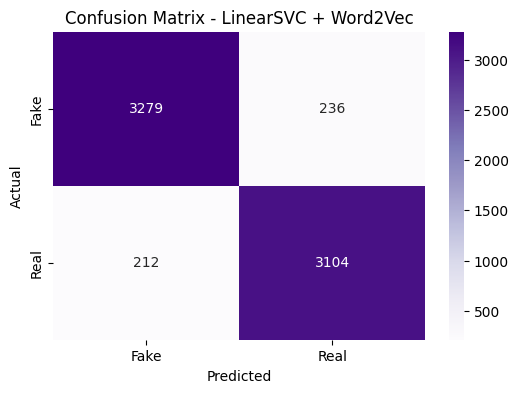

In [19]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create LinearSVC model
svm_model = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=5000
)

# Train model on Word2Vec document vectors
svm_model.fit(X_train, y_train)

# Predict on training and validation data
train_preds = svm_model.predict(X_train)
val_preds = svm_model.predict(X_val)

# Calculate metrics
metrics = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Val Accuracy": accuracy_score(y_val, val_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Val F1": f1_score(y_val, val_preds)
}

# Print results
print("--- LinearSVC + Word2Vec Results ---")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nDetailed Classification Report (Validation Set):")
print(classification_report(y_val, val_preds, target_names=["Fake (0)", "Real (1)"]))

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_val, val_preds),
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("Confusion Matrix - LinearSVC + Word2Vec")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()